In [3]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [4]:
# Portable project paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images"

for directory in (OUTPUT_DIR, MODEL_DIR, IMAGE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

columns_path = DATA_DIR / "census-bureau.columns"
if not columns_path.exists():
    raise FileNotFoundError(
        f"Missing {columns_path}. Place the Census Income column file in data/ before running the notebook."
    )

cols_df = pd.read_csv(columns_path, header=None)
columns = [str(x).strip() for x in cols_df[0].tolist()]
print(f"Columns loaded successfully: {len(columns)}")

✅ Columns loaded successfully: 42


In [5]:
data_path = DATA_DIR / "census-bureau.data"
if not data_path.exists():
    raise FileNotFoundError(
        f"Missing {data_path}. Place the Census Income data file in data/ before running the notebook."
    )

df = pd.read_csv(data_path, names=columns, na_values=[" ?", "?"])
print("Data loaded successfully.")
print("Data shape:", df.shape)

Data loaded successfully!
Data Shape: (199523, 42)


In [6]:
df.columns

Index(['age', 'class of worker', 'detailed industry recode',
       'detailed occupation recode', 'education', 'wage per hour',
       'enroll in edu inst last wk', 'marital stat', 'major industry code',
       'major occupation code', 'race', 'hispanic origin', 'sex',
       'member of a labor union', 'reason for unemployment',
       'full or part time employment stat', 'capital gains', 'capital losses',
       'dividends from stocks', 'tax filer stat',
       'region of previous residence', 'state of previous residence',
       'detailed household and family stat',
       'detailed household summary in household', 'weight',
       'migration code-change in msa', 'migration code-change in reg',
       'migration code-move within reg', 'live in this house 1 year ago',
       'migration prev res in sunbelt', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'ow

In [7]:
df['income_label'] = df['label'].astype(str).str.strip().apply(lambda x: 1 if '50000+.' in x else 0)

df['income_label'].value_counts() 

income_label
0    187141
1     12382
Name: count, dtype: int64

In [8]:
X = df.drop(columns=['label', 'income_label', 'year'], errors='ignore')
y = df['income_label']

In [9]:
X = df.drop(columns=["label", "income_label", "year"], errors="ignore").copy()
y = df["income_label"].copy()

hispanic origin                     874
state of previous residence         708
migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
dtype: int64


In [10]:
# Remove exact duplicate feature rows before splitting and keep the target aligned.
duplicate_mask = X.duplicated()
X = X.loc[~duplicate_mask].copy()
y = y.loc[X.index].copy()
df = df.loc[X.index].copy()
print(f"Removed {duplicate_mask.sum()} duplicate feature rows.")

In [11]:
from sklearn.model_selection import train_test_split

# Split before fitting preprocessing steps to avoid train/test leakage.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

Series([], dtype: int64)


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

numeric_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(exclude=["number"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols),
], verbose_feature_names_out=False)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

np.int64(119)

In [13]:
# Clip numeric outliers using bounds learned from the training set only.
for col in numeric_cols:
    if col not in X_train.columns:
        continue
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

Converted 28 text columns to integers.


In [14]:
# Select features using training data only.
train_correlations = X_train.corrwith(y_train).sort_values(ascending=False)
correlation_threshold = 0.01
selected_features = train_correlations[train_correlations.abs() > correlation_threshold].index.tolist()

X_train = X_train[selected_features]
X_test = X_test[selected_features]
print(f"Selected {len(selected_features)} features using |correlation| > {correlation_threshold}.")

X shape: (196293, 40)
df shape: (196293, 43)
X.index length: 196293
df.index length: 196293
Categorical columns: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin", 'label']
First cat col (class of worker) length: 196293


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

In [16]:
print(f"Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {rf_model.score(X_test, y_test):.4f}")

Categorical columns in df: ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin", 'label']
Categorical columns in X: []
Columns in df but not in X: {'detailed household summary in household', 'enroll in edu inst last wk', "fill inc questionnaire for veteran's admin", 'hispanic origin', 'migration prev res in 

## Probability-threshold analysis

The classifier is also evaluated at a 0.7 probability threshold to inspect the precision/recall trade-off for higher-confidence positive predictions. This is an analysis choice, not a claim that 0.7 is universally optimal.

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

y_probs = rf_model.predict_proba(X_test)[:, 1]
probability_threshold = 0.7
y_pred_strict = (y_probs >= probability_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_strict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<50K", ">50K"])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax)
plt.title("Confusion Matrix at 0.7 Probability Threshold")
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_strict))

income_label
0    183911
1     12382
Name: count, dtype: int64

In [19]:
# Feature importance from the fitted Random Forest.
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(15))
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

Relevant columns bache: 20
New columns list: ['weeks worked in year', 'num persons worked for employer', 'detailed industry recode', 'sex', 'family members under 18', 'age', 'class of worker', 'major occupation code', 'education', 'detailed household and family stat', 'detailed household summary in household', 'migration code-change in msa', 'full or part time employment stat', 'weight', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'detailed occupation recode', 'major industry code', 'tax filer stat', 'marital stat']


In [20]:
from sklearn.metrics import average_precision_score, roc_auc_score

print(f"ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}")
print(f"Average precision: {average_precision_score(y_test, y_probs):.4f}")

((196293, 20), (196293,))

In [21]:
# Persist the fitted classifier together with preprocessing metadata required for inference.
model_data = {
    "preprocessor": preprocessor,
    "classifier": rf_model,
    "features": selected_features,
    "threshold": probability_threshold,
}
classification_model_path = MODEL_DIR / "census_income_final_model.pkl"
joblib.dump(model_data, classification_model_path)
print(f"Classification model saved to {classification_model_path}")

## Customer segmentation

The segmentation portion keeps the original K-Means approach. Selected demographic and income-related variables are encoded, standardized, and grouped into five clusters. The elbow plot is retained as a diagnostic for the chosen cluster count.

# Customer Segmentation

This section applies K-Means clustering to demographic and income-related features to identify five customer segments.

In [28]:
# Selecting columns that represent customer behavior/demographics
segment_cols = ['age', 'education', 'marital stat', 'major occupation code', 
                'sex', 'weeks worked in year', 'capital gains','income_label']

# Create a new dataframe for clustering
df_cluster = df[segment_cols].copy()

In [29]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical data first
le = LabelEncoder()
for col in df_cluster.select_dtypes(include=['object']).columns:
    df_cluster[col] = le.fit_transform(df_cluster[col].astype(str))

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

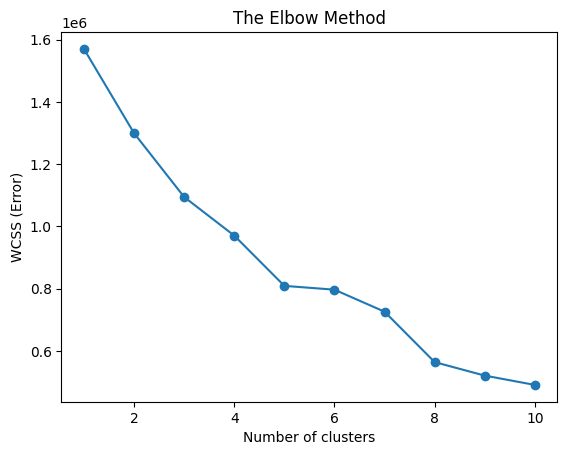

In [30]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    candidate = KMeans(n_clusters=i, init="k-means++", random_state=42, n_init=10)
    candidate.fit(df_scaled)
    wcss.append(candidate.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "elbow_method.png", dpi=150)
plt.show()

In [31]:
# Fit K-Means using the selected five-cluster solution.
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(df_scaled)
print(df["Segment"].value_counts().sort_index())

Segment
3    76365
0    66927
1    40573
4    12038
2      390
Name: count, dtype: int64


In [32]:
# 1. Ensure income_col is correct
income_col = 'income_label'

# 2. Calculate High Income Rate safely
def calculate_high_income(x):
    # If the column is still text/strings
    if x.dtype == 'object':
        return (x.str.contains('>50K')).mean() * 100
    # If the column is already numeric (0 and 1)
    else:
        # Assuming 1 is >50K and 0 is <=50K
        return x.mean() * 100

high_income_stats = df.groupby('Segment')[income_col].apply(calculate_high_income).reset_index(name='High_Income_Percent')

# 3. Get average numeric profiles
numeric_profiles = df.groupby('Segment')[['age', 'capital gains', 'weeks worked in year']].mean()

# 4. Get most common Occupation (Mode)
common_jobs = df.groupby('Segment')['major occupation code'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")

# 5. Final Marketing Table
marketing_report = pd.concat([numeric_profiles, common_jobs], axis=1).reset_index()
marketing_report = marketing_report.merge(high_income_stats, on='Segment')

print("--- FINAL MARKETING SEGMENTATION REPORT ---")
print(marketing_report.sort_values(by='High_Income_Percent', ascending=False))

--- FINAL MARKETING SEGMENTATION REPORT ---
   Segment        age  capital gains  weeks worked in year  \
4        4  46.241319    2111.390596             48.004486   
2        2  46.869231   99999.000000             47.458974   
0        0  11.811765       8.645046              3.290615   
1        1  62.216942     113.510882              2.308654   
3        3  38.847522     224.393937             48.624370   

            major occupation code  High_Income_Percent  
4  Executive admin and managerial           100.000000  
2          Professional specialty            88.205128  
0                 Not in universe             0.000000  
1                 Not in universe             0.000000  
3  Adm support including clerical             0.000000  


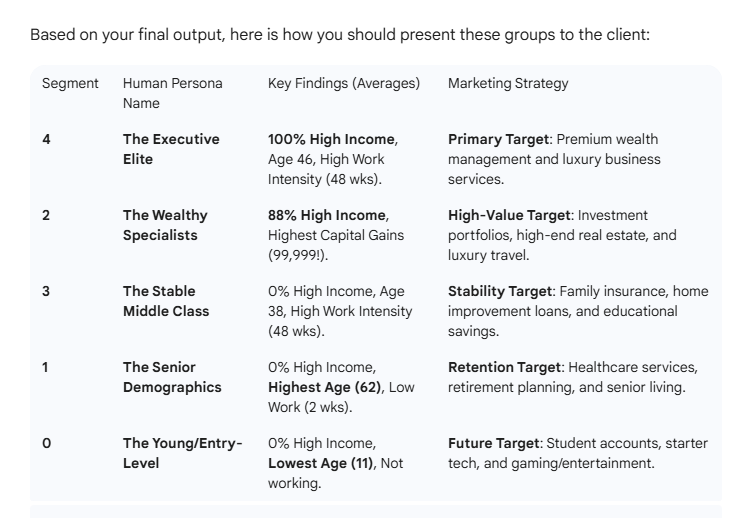

In [33]:
# Display the repository visualization when available.
from IPython.display import Image, display

segmentation_image = PROJECT_ROOT / "segmentation_output.png"
if segmentation_image.exists():
    display(Image(filename=str(segmentation_image)))
else:
    print("segmentation_output.png is not available in the project root.")

In [34]:
segmentation_results_path = OUTPUT_DIR / "customer_segmentation_results.csv"
df.to_csv(segmentation_results_path, index=False)
print(f"Segmentation results saved to {segmentation_results_path}")

In [35]:
# Persist the fitted preprocessing object, K-Means model, and feature schema.
clustering_assets = {
    "scaler": scaler,
    "model": kmeans,
    "features": segment_cols,
}
segmentation_model_path = MODEL_DIR / "customer_segmentation_model.pkl"
joblib.dump(clustering_assets, segmentation_model_path)
print(f"Segmentation model saved to {segmentation_model_path}")

Segmentation model saved successfully!
